# MediaPipe Frame Extractor
Run MediaPipe on a single video and extract frames with landmark overlays for your poster.

In [20]:
!pip install mediapipe opencv-python-headless matplotlib Pillow

In [29]:
import os, urllib.request
import numpy as np
import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python.vision import HolisticLandmarker, HolisticLandmarkerOptions
from mediapipe.tasks.python.vision.core.vision_task_running_mode import VisionTaskRunningMode
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

# ── CONFIG ────────────────────────────────────────────────────────────────────
VIDEO_PATH   = 'UAE100/Animals/Animals_03_Cat.mp4'   # ← change to your video
MP_MODEL     = 'models/holistic_landmarker.task'
OUTPUT_DIR   = 'poster_frames'
SIGN_LABEL   = 'Cat'                             # ← label shown in captions

# How many frames to extract and show
N_FRAMES     = 4  # number of frames to display

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'✅ Config ready | Label: {SIGN_LABEL}')

✅ Config ready | Label: Cat


In [22]:
# ── Landmark drawing helpers ───────────────────────────────────────────────────
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17),
]
POSE_CONNECTIONS = [
    (11,12),(11,13),(13,15),(12,14),(14,16),(11,23),(12,24),(23,24),
]
FACE_INDICES = [152, 10, 234, 454]

# Colors BGR
COL_LEFT_HAND  = (130, 220, 80)    # green
COL_RIGHT_HAND = (255, 130, 180)   # purple/pink
COL_POSE       = (255, 200, 100)   # cyan
COL_FACE       = (100, 220, 255)   # yellow

def draw_connections(img, lms, connections, color, thickness=2):
    h, w = img.shape[:2]
    for a, b in connections:
        if a < len(lms) and b < len(lms):
            p1 = (int(lms[a].x * w), int(lms[a].y * h))
            p2 = (int(lms[b].x * w), int(lms[b].y * h))
            cv2.line(img, p1, p2, color, thickness, cv2.LINE_AA)

def draw_points(img, lms, color, radius=4, indices=None):
    h, w = img.shape[:2]
    src = [lms[i] for i in indices] if indices else lms
    for lm in src:
        cx, cy = int(lm.x * w), int(lm.y * h)
        cv2.circle(img, (cx, cy), radius, color, -1, cv2.LINE_AA)
        cv2.circle(img, (cx, cy), radius+1, (255,255,255), 1, cv2.LINE_AA)

def draw_landmarks_on_frame(frame_bgr, result, alpha=0.85):
    """Draw all landmarks on a copy of the frame. Returns overlay image."""
    overlay = frame_bgr.copy()

    if result.pose_landmarks:
        draw_connections(overlay, result.pose_landmarks, POSE_CONNECTIONS, COL_POSE, 2)
        draw_points(overlay, result.pose_landmarks, COL_POSE, 3)

    if result.left_hand_landmarks:
        draw_connections(overlay, result.left_hand_landmarks, HAND_CONNECTIONS, COL_LEFT_HAND, 2)
        draw_points(overlay, result.left_hand_landmarks, COL_LEFT_HAND, 4)

    if result.right_hand_landmarks:
        draw_connections(overlay, result.right_hand_landmarks, HAND_CONNECTIONS, COL_RIGHT_HAND, 2)
        draw_points(overlay, result.right_hand_landmarks, COL_RIGHT_HAND, 4)

    if result.face_landmarks:
        draw_points(overlay, result.face_landmarks, COL_FACE, 3, FACE_INDICES)

    # Blend overlay with original for semi-transparent effect
    out = cv2.addWeighted(overlay, alpha, frame_bgr, 1 - alpha, 0)
    return out

print('✅ Drawing helpers ready')
print('   Green  = left hand (21 nodes)')
print('   Purple = right hand (21 nodes)')
print('   Cyan   = pose joints (9 nodes)')
print('   Yellow = face reference points (4 nodes)')

✅ Drawing helpers ready
   Green  = left hand (21 nodes)
   Purple = right hand (21 nodes)
   Cyan   = pose joints (9 nodes)
   Yellow = face reference points (4 nodes)


In [30]:
# ── Extract ALL frames with landmarks ─────────────────────────────────────────
options = HolisticLandmarkerOptions(
    base_options     = mp_python.BaseOptions(model_asset_path=MP_MODEL),
    running_mode     = VisionTaskRunningMode.VIDEO,
    min_face_detection_confidence = 0.5,
    min_pose_detection_confidence = 0.5,
    min_hand_landmarks_confidence = 0.5,
    output_face_blendshapes       = False,
    output_segmentation_mask      = False,
)

cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), f'Cannot open video: {VIDEO_PATH}'

fps      = cap.get(cv2.CAP_PROP_FPS) or 30.0
total    = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = total / fps

print(f'Video: {VIDEO_PATH}')
print(f'  {total} frames  |  {fps:.1f} fps  |  {duration:.2f}s')

# Store all extracted frames and results
frames_raw      = []   # original BGR
frames_overlay  = []   # with landmarks drawn
detection_rates = []

ts = 0

with HolisticLandmarker.create_from_options(options) as lm:
    for i in range(total):
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (640, 480))
        rgb   = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mpi   = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        res   = lm.detect_for_video(mpi, ts)
        ts   += 1

        has_hand = (
            (res.left_hand_landmarks  and len(res.left_hand_landmarks)  > 0) or
            (res.right_hand_landmarks and len(res.right_hand_landmarks) > 0)
        )

        overlay = draw_landmarks_on_frame(frame, res)
        frames_raw.append(frame)
        frames_overlay.append(overlay)
        detection_rates.append(1 if has_hand else 0)

cap.release()

det_rate = sum(detection_rates) / len(detection_rates)
print(f'\n✅ Extracted {len(frames_raw)} frames')
print(f'   Hand detection rate: {det_rate:.1%}')

# Frames where hands were detected
detected_indices = [i for i, d in enumerate(detection_rates) if d == 1]
print(f'   Frames with hands  : {len(detected_indices)}')

Video: UAE100/Animals/Animals_03_Cat.mp4
  250 frames  |  25.0 fps  |  10.00s


I0000 00:00:1781717781.631734   59016 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1781717781.651450   59031 gl_context.cc:385] GL version: 3.1 (OpenGL ES 3.1 Mesa 23.2.1-1ubuntu3.1~22.04.4), renderer: D3D12 (NVIDIA GeForce RTX 3080)
W0000 00:00:1781717781.697311   59021 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781717781.715007   59024 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781717781.717140   59028 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781717781.718148   59019 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



✅ Extracted 250 frames
   Hand detection rate: 17.2%
   Frames with hands  : 43


In [31]:
# ── Pick the BEST frames for the poster ───────────────────────────────────────
# Strategy: evenly spaced frames from the detected region (not start/end silence)

if len(detected_indices) == 0:
    print('⚠️  No hands detected — using evenly spaced frames from full video')
    indices_to_show = np.linspace(0, total - 1, N_FRAMES, dtype=int).tolist()
else:
    # Use middle 80% of detected frames (skip brief start/end)
    trim   = int(len(detected_indices) * 0.1)
    core   = detected_indices[trim : -trim if trim > 0 else None]
    if len(core) < N_FRAMES:
        core = detected_indices
    step   = max(1, len(core) // N_FRAMES)
    indices_to_show = [core[i * step] for i in range(N_FRAMES)]

print(f'Selected frames: {indices_to_show}')
print(f'Timestamps     : {[f"{i/fps:.2f}s" for i in indices_to_show]}')

Selected frames: [21, 29, 37, 59]
Timestamps     : ['0.84s', '1.16s', '1.48s', '2.36s']


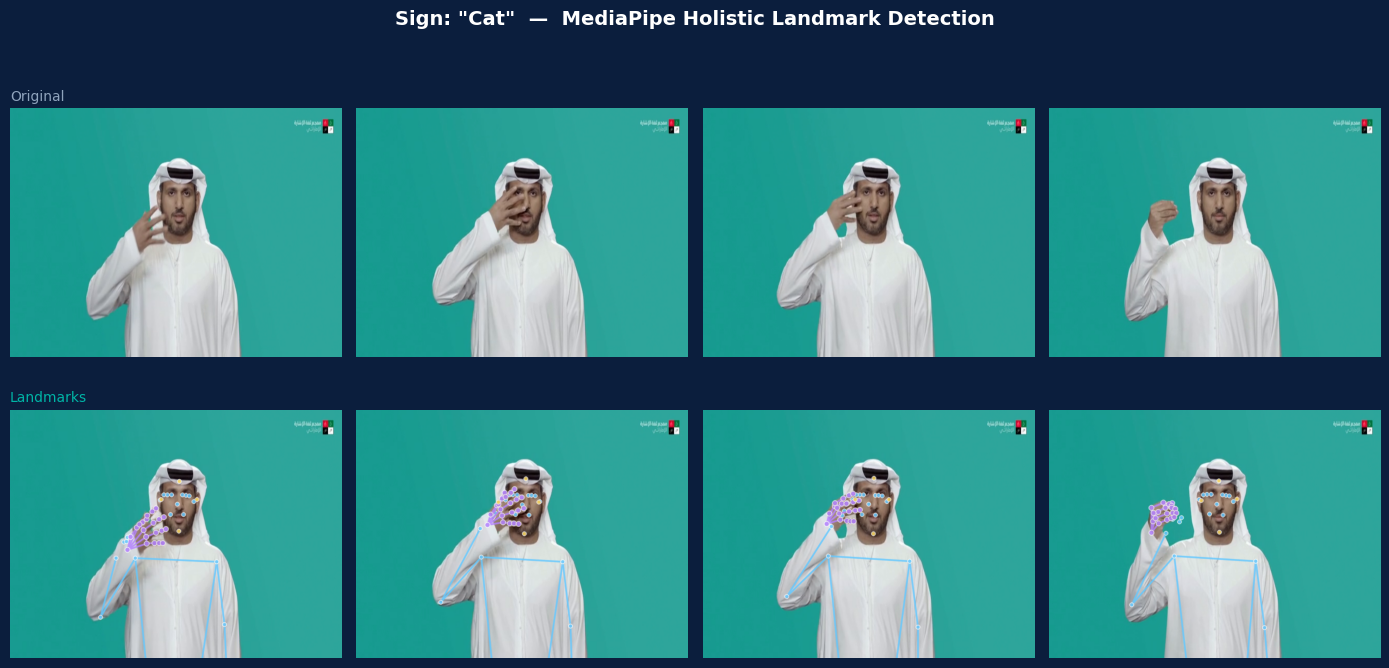

✅ Saved: poster_frames/Cat_comparison_grid.png


In [32]:
# ── Display: side-by-side raw vs overlay ──────────────────────────────────────
fig, axes = plt.subplots(2, N_FRAMES, figsize=(N_FRAMES * 3.5, 7))
fig.patch.set_facecolor('#0B1E3D')
fig.suptitle(
    f'Sign: "{SIGN_LABEL}"  —  MediaPipe Holistic Landmark Detection',
    fontsize=14, color='white', fontweight='bold', y=1.01
)

for col, idx in enumerate(indices_to_show):
    ts_label = f'Frame {idx}  ({idx/fps:.2f}s)'

    # Row 0 — raw frame
    ax0 = axes[0, col]
    ax0.imshow(cv2.cvtColor(frames_raw[idx], cv2.COLOR_BGR2RGB))
    ax0.axis('off')
    if col == 0:
        ax0.set_title('Original', color='#8FA3BC', fontsize=10, loc='left')
    ax0.set_xlabel(ts_label, color='#8FA3BC', fontsize=8)

    # Row 1 — overlay
    ax1 = axes[1, col]
    ax1.imshow(cv2.cvtColor(frames_overlay[idx], cv2.COLOR_BGR2RGB))
    ax1.axis('off')
    if col == 0:
        ax1.set_title('Landmarks', color='#00B4A6', fontsize=10, loc='left')
    ax1.set_xlabel(ts_label, color='#8FA3BC', fontsize=8)

for ax in axes.flat:
    ax.set_facecolor('#0B1E3D')

plt.tight_layout()

# Save full comparison grid
out_grid = os.path.join(OUTPUT_DIR, f'{SIGN_LABEL}_comparison_grid.png')
plt.savefig(out_grid, dpi=200, bbox_inches='tight', facecolor='#0B1E3D')
plt.show()
print(f'✅ Saved: {out_grid}')

In [ ]:
# ── Save individual frames (overlay only) for Figma import ────────────────────
# These are the files you drag into Figma for the poster

print(f'Saving {N_FRAMES} individual overlay frames to {OUTPUT_DIR}/ ...')

for rank, idx in enumerate(indices_to_show):
    frame_overlay_rgb = cv2.cvtColor(frames_overlay[idx], cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(frame_overlay_rgb)
    fname   = os.path.join(OUTPUT_DIR, f'{SIGN_LABEL}_frame_{rank+1:02d}_f{idx}.png')
    img_pil.save(fname)
    print(f'  ✅ {fname}  (frame {idx}, t={idx/fps:.2f}s)')

print(f'\nAlso saving raw (no overlay) versions ...')
for rank, idx in enumerate(indices_to_show):
    frame_raw_rgb = cv2.cvtColor(frames_raw[idx], cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(frame_raw_rgb)
    fname   = os.path.join(OUTPUT_DIR, f'{SIGN_LABEL}_raw_frame_{rank+1:02d}_f{idx}.png')
    img_pil.save(fname)

print(f'\n✅ All frames saved to {OUTPUT_DIR}/')
print(f'   Files to import into Figma:')
for rank in range(N_FRAMES):
    print(f'   {SIGN_LABEL}_frame_{rank+1:02d}_*.png  ← overlay')
    print(f'   {SIGN_LABEL}_raw_frame_{rank+1:02d}_*.png  ← clean')

In [ ]:
# ── OPTIONAL: Manually pick specific frames ────────────────────────────────────
# If you want specific frame numbers instead of auto-selected ones:

MANUAL_FRAMES = []   # ← e.g. [15, 30, 45, 60, 75, 90] — leave empty to skip

if MANUAL_FRAMES:
    fig, axes = plt.subplots(1, len(MANUAL_FRAMES), figsize=(len(MANUAL_FRAMES) * 3.5, 4))
    if len(MANUAL_FRAMES) == 1:
        axes = [axes]

    for i, idx in enumerate(MANUAL_FRAMES):
        idx = min(idx, len(frames_overlay) - 1)
        axes[i].imshow(cv2.cvtColor(frames_overlay[idx], cv2.COLOR_BGR2RGB))
        axes[i].axis('off')
        axes[i].set_title(f'Frame {idx}\n{idx/fps:.2f}s', fontsize=9, color='#0A7EA4')

    fig.suptitle(f'Manual selection — {SIGN_LABEL}', fontsize=12, fontweight='bold')
    plt.tight_layout()

    out = os.path.join(OUTPUT_DIR, f'{SIGN_LABEL}_manual_selection.png')
    plt.savefig(out, dpi=200, bbox_inches='tight')
    plt.show()

    # Save individually too
    for i, idx in enumerate(MANUAL_FRAMES):
        idx = min(idx, len(frames_overlay) - 1)
        img = Image.fromarray(cv2.cvtColor(frames_overlay[idx], cv2.COLOR_BGR2RGB))
        img.save(os.path.join(OUTPUT_DIR, f'{SIGN_LABEL}_manual_{i+1:02d}_f{idx}.png'))
    print(f'✅ Manual frames saved')
else:
    print('Manual frame selection skipped (MANUAL_FRAMES is empty)')
    print('To use: set MANUAL_FRAMES = [10, 20, 30, 40, 50, 60] and re-run this cell')

In [ ]:
# ── BONUS: Poster-ready strip (all overlay frames in one dark strip) ───────────
# One wide image perfect for pasting directly into Figma

FRAME_H    = 320   # height of each frame in the strip (pixels)
FRAME_W    = int(640 * FRAME_H / 480)
GAP        = 12
BG_COLOR   = (11, 30, 61)   # #0B1E3D in BGR

strip_w = N_FRAMES * FRAME_W + (N_FRAMES + 1) * GAP
strip_h = FRAME_H + GAP * 2 + 36   # extra for label

strip = np.full((strip_h, strip_w, 3), BG_COLOR, dtype=np.uint8)

for i, idx in enumerate(indices_to_show):
    resized   = cv2.resize(frames_overlay[idx], (FRAME_W, FRAME_H))
    x_start   = GAP + i * (FRAME_W + GAP)
    strip[GAP:GAP+FRAME_H, x_start:x_start+FRAME_W] = resized

    # Frame label
    label = f'{idx/fps:.1f}s'
    cv2.putText(strip, label,
                (x_start + 5, GAP + FRAME_H + 22),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (143, 163, 188), 1, cv2.LINE_AA)

# Sign label on the strip
cv2.putText(strip, SIGN_LABEL,
            (GAP, GAP - 4),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 180, 166), 1, cv2.LINE_AA)

strip_rgb = cv2.cvtColor(strip, cv2.COLOR_BGR2RGB)
strip_out = os.path.join(OUTPUT_DIR, f'{SIGN_LABEL}_poster_strip.png')
Image.fromarray(strip_rgb).save(strip_out)

plt.figure(figsize=(16, 3))
plt.imshow(strip_rgb)
plt.axis('off')
plt.title(f'{SIGN_LABEL} — Poster Strip', color='white')
plt.gca().set_facecolor('#0B1E3D')
plt.gcf().set_facecolor('#0B1E3D')
plt.tight_layout()
plt.show()
print(f'✅ Poster strip saved: {strip_out}')
print(f'   Import this PNG directly into Figma for the methodology section')

In [ ]:
# ── Summary ────────────────────────────────────────────────────────────────────
print('=== All output files ===' )
for f in sorted(os.listdir(OUTPUT_DIR)):
    full = os.path.join(OUTPUT_DIR, f)
    size = os.path.getsize(full) / 1024
    print(f'  {f:<55} {size:>7.1f} KB')

print(f'\n=== Import guide for Figma ===')
print(f'  *_poster_strip.png     → drop into Methodology section as one image')
print(f'  *_frame_XX_*.png       → individual overlay frames (use for 2×3 grid)')
print(f'  *_raw_frame_XX_*.png   → clean frames (use for before/after comparison)')
print(f'  *_comparison_grid.png  → full grid overview (reference only)')